======================================================= <br>
This notebook generates a flat prior from an InTEM file. <br>
======================================================= <br>

Author: Helene De Longueville <br>
Project: PARIS <br>
Year: 2024

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import glob

from datetime import datetime 
from openghg.standardise import standardise_flux 

## A. Inputs

In [2]:
species = ['hfc236fa'] #['hfc152a','hfc23','hfc227ea','hfc245fa','hfc365mfc','hfc4310mee']
data_dir = '/user/home/qq24644/work/my_paris/InTEM_flat_prior/'
data_type = '*_uniformflatlandnosea_*.nc'
output_dir = '/user/home/qq24644/work/my_paris/InTEM_flat_prior/openghg/'
output_type = '_EUROPE_FLAT_UNIFORM.nc'
years = np.arange('2012-01-01', '2024-01-01', dtype='datetime64[Y]')
dates = [np.datetime64(year, 'D') for year in years]

## B. Generate new netcdf files

In [3]:
for target in species:
    if target == 'hfc365mfc':
        files = data_dir+'hfc365'+data_type
    else:
        files = data_dir+target+data_type
    file_list = glob.glob(files)
    with xr.open_mfdataset(file_list, combine='by_coords') as intem:
        intem = intem

    note = intem.attrs.get('to_note')
    intem.attrs.clear()
    intem['flux'].attrs.clear()

    with xr.open_dataset('/group/chemistry/acrg/LPDM/emissions/EUROPE/h-1301_EUROPE_2009.nc') as template:
        template = template

    if len(file_list) == 1:
        flat = xr.concat([intem] * len(dates), dim='time')
        flat['time'] = dates
    else:
        flat = intem    

    flat['lat'] = template['lat'].values
    flat['lon'] = template['lon'].values

    if target == 'pfc218':
        flat.attrs['species'] = 'c3f8'
    elif target == 'pfc116':
        flat.attrs['species'] = 'c2f6'
    else:
        flat.attrs['species'] = target

    flat.attrs['description'] = note
    flat.attrs['created_from'] = files
    flat.attrs['created_by'] = 'qq24644'
    flat.attrs['creation_on'] = str(datetime.today())

    output_name = output_dir+target+output_type
    flat.to_netcdf(output_name, "w")

## C. Check data plot

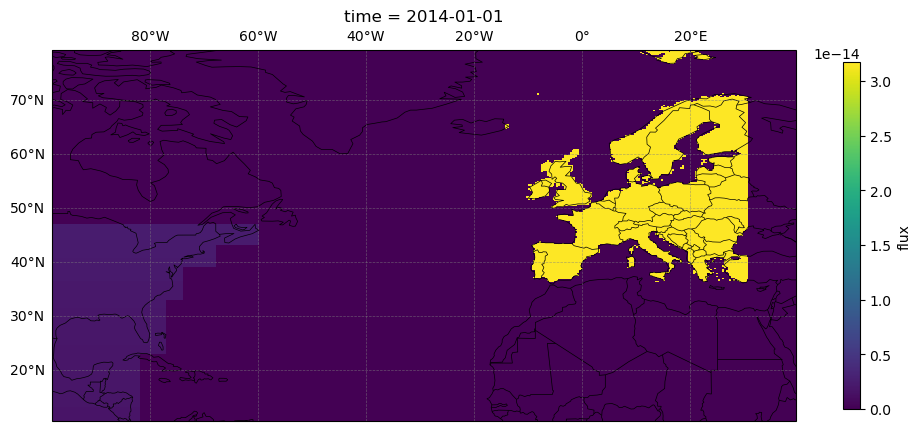

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,10))
flat.flux[:,:,2].plot(ax=ax, transform=ccrs.PlateCarree(), robust=True, cbar_kwargs={"shrink":0.45})
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl.right_labels = False
gl.bottom_labels = False

## D. Populate object store

In [5]:
species = ['hfc236fa'] #['hfc152a','hfc23','hfc227ea','hfc245fa','hfc365mfc','hfc4310mee']
data_dir = '/user/home/qq24644/work/my_paris/InTEM_flat_prior/openghg/'
data_type = '_EUROPE_FLAT_UNIFORM.nc'
store = 'paris_store_zarr'
source = 'flat-annual-total'

In [6]:
for target in species:
    if target == 'pfc218':
        spec = 'c3f8'
    elif target == 'pfc116':
        spec = 'c2f6'
    elif target == 'pfc318':
        spec = 'c4f8'
    else:
        spec = target
    domain = 'EUROPE'
    source_format = 'openghg'

    fn = data_dir + target + data_type
    print('Processing ' + fn)
    standardise_flux(filepath=fn, species = spec, domain = domain, source = source, source_format = source_format, store = store, if_exists = "new", save_current = "yes", force = True)


Processing /user/home/qq24644/work/my_paris/InTEM_flat_prior/openghg/hfc236fa_EUROPE_FLAT_UNIFORM.nc
